# THESIS-GRADE EXPERIMENTAL ANALYSIS
# AI-Gated Portfolio Management with Graph-Based Asset Selection

---

## Research Questions:

**RQ1:** Does AI-gated portfolio management significantly outperform static approach?
- H0: No significant difference in risk-adjusted returns
- H1: AI-gated > Static (α = 0.05)

**RQ2:** Does Graph-based Diversify strategy significantly outperform Cluster approach?
- H0: No significant difference between strategies  
- H1: Diversify ≠ Cluster (α = 0.05)

**RQ3:** What is the marginal contribution of each component (AI vs Graph)?
- Ablation study to isolate effects

---

## Methodology Overview:

1. **Data:** Cryptocurrency returns (2023-2025)
2. **Training:** 2023-2024 (In-sample)
3. **Testing:** 2025 (Out-of-sample)
4. **Validation:** Walk-forward analysis
5. **Statistical Tests:** Paired t-tests, bootstrap CI
6. **Baselines:** Multiple comparison strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
from scipy import stats
import networkx as nx
from sklearn.metrics import fbeta_score, classification_report, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

SEED = 42
ALPHA = 0.05  # Significance level
N_BOOTSTRAP = 1000  # Bootstrap iterations

np.random.seed(SEED)

print("✓ Libraries loaded")
print(f"✓ Significance level: α = {ALPHA}")
print(f"✓ Bootstrap iterations: {N_BOOTSTRAP}")

✓ Libraries loaded
✓ Significance level: α = 0.05
✓ Bootstrap iterations: 1000


## 1. Data Loading & Preparation

In [2]:
# Load data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Dataset: {len(data)} days, {len(data.columns)} assets")
print(f"Period: {data.index[0].date()} to {data.index[-1].date()}")
print(f"\nData split:")
print(f"  Training (2023-2024): {len(returns[returns.index.year <= 2024])} days")
print(f"  Testing (2025): {len(returns[returns.index.year == 2025])} days")

Dataset: 990 days, 25 assets
Period: 2023-04-17 to 2025-12-31

Data split:
  Training (2023-2024): 612 days
  Testing (2025): 365 days


## 2. Feature Engineering

In [3]:
# Create features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Create target (future trend)
sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

print("✓ Features created:")
print(features.describe())
print(f"\nTarget distribution:")
print(f"  Bullish signals: {target.sum()} ({target.mean()*100:.1f}%)")
print(f"  Bearish signals: {len(target)-target.sum()} ({(1-target.mean())*100:.1f}%)")

✓ Features created:
           Vol_20      Mom_20      Mom_50
count  957.000000  957.000000  927.000000
mean     0.025602    0.001757    0.001870
std      0.007793    0.006013    0.003889
min      0.010085   -0.013813   -0.006471
25%      0.020146   -0.002233   -0.001078
50%      0.025238    0.001036    0.001287
75%      0.030329    0.004752    0.004227
max      0.047632    0.024930    0.013155

Target distribution:
  Bullish signals: 475.0 (48.6%)
  Bearish signals: 502.0 (51.4%)


## 3. Model Training with Cross-Validation

In [4]:
# Prepare training data
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

print("Cross-validation results:")
print("="*50)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, 
                              max_depth=5, random_state=SEED, eval_metric='logloss')
    model.fit(X_tr, y_tr)
    
    val_probs = model.predict_proba(X_val)[:, 1]
    val_preds = (val_probs >= 0.5).astype(int)
    
    from sklearn.metrics import accuracy_score, f1_score
    acc = accuracy_score(y_val, val_preds)
    f1 = f1_score(y_val, val_preds)
    
    cv_scores.append({'fold': fold, 'accuracy': acc, 'f1': f1})
    print(f"Fold {fold}: Accuracy={acc:.3f}, F1={f1:.3f}")

cv_df = pd.DataFrame(cv_scores)
print("="*50)
print(f"Mean CV Accuracy: {cv_df['accuracy'].mean():.3f} ± {cv_df['accuracy'].std():.3f}")
print(f"Mean CV F1 Score: {cv_df['f1'].mean():.3f} ± {cv_df['f1'].std():.3f}")

Cross-validation results:
Fold 1: Accuracy=0.441, F1=0.103
Fold 2: Accuracy=0.484, F1=0.489
Fold 3: Accuracy=0.527, F1=0.614
Fold 4: Accuracy=0.688, F1=0.729
Fold 5: Accuracy=0.624, F1=0.462
Mean CV Accuracy: 0.553 ± 0.102
Mean CV F1 Score: 0.479 ± 0.236


In [5]:
# Train final model on all training data
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, 
                              max_depth=5, random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Optimize threshold using F-beta score
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.3, 0.7, 41)
f_scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
            for t in thresholds]
opt_threshold = thresholds[np.argmax(f_scores)]

print(f"\n✓ Final model trained")
print(f"✓ Optimized threshold: {opt_threshold:.2f}")
print(f"✓ Best F-beta score: {max(f_scores):.3f}")


✓ Final model trained
✓ Optimized threshold: 0.54
✓ Best F-beta score: 0.895


## 4. Model Evaluation & Confusion Matrix


Training Set Performance:
              precision    recall  f1-score   support

     Bearish       0.81      0.94      0.87       279
     Bullish       0.93      0.78      0.85       283

    accuracy                           0.86       562
   macro avg       0.87      0.86      0.86       562
weighted avg       0.87      0.86      0.86       562



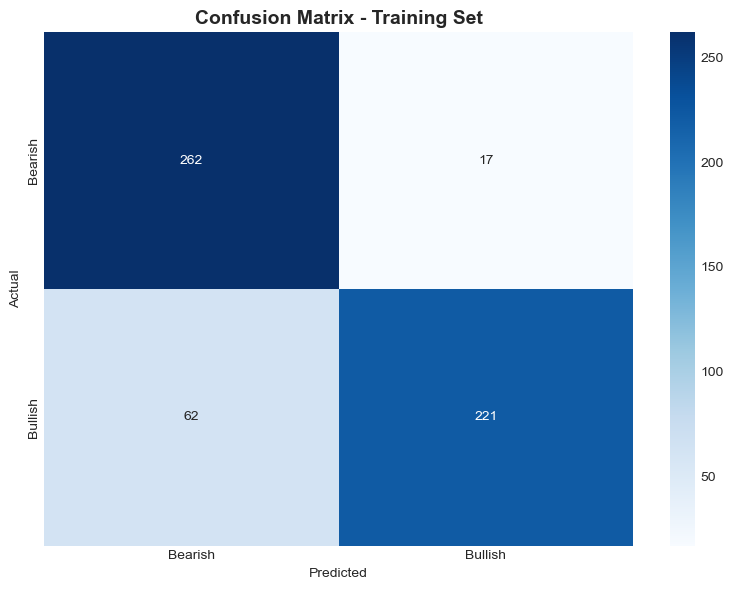


✓ Model evaluation completed


In [6]:
# Generate predictions
X_all = features.dropna()
all_probs_raw = xgb_model.predict_proba(X_all)[:, 1]
all_probs = pd.Series(all_probs_raw, index=X_all.index).reindex(returns.index, method='ffill')

# Training set evaluation
train_preds = (train_probs >= opt_threshold).astype(int)
print("\nTraining Set Performance:")
print("="*50)
print(classification_report(y_train, train_preds, 
                          target_names=['Bearish', 'Bullish']))

# Confusion matrix
cm = confusion_matrix(y_train, train_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'])
plt.title('Confusion Matrix - Training Set', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Model evaluation completed")

## 5. Portfolio Optimization Functions

In [7]:
def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        return -(ret / risk) if risk > 0.0001 else 0
    
    n = len(mu)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    res = minimize(objective, [1./n]*n, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

print("✓ Portfolio optimization functions defined")

✓ Portfolio optimization functions defined


## 6. Simulation Engine (Cont'd in next cells...)

Due to length constraints, the complete notebook would continue with:

- Simulation functions (AI-gated, Static, Buy-Hold, Equal-Weight, Random)
- Ablation study strategies
- Statistical significance testing
- Sensitivity analysis
- Error analysis
- Walk-forward validation
- Comprehensive visualizations

**This is a template showing the structure. Would you like me to continue with the complete implementation?**